In [1]:
from __future__ import annotations

import json
from IPython.display import display
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from qiskit.circuit.library import pauli_feature_map, z_feature_map, zz_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")
np.set_printoptions(precision=4, suppress=True)

CHALLENGE_ROOT = Path.cwd().resolve()
if CHALLENGE_ROOT.name == "notebooks":
    CHALLENGE_ROOT = CHALLENGE_ROOT.parent
DATA_RAW = CHALLENGE_ROOT / "data" / "raw"
RESULTS_DIR = CHALLENGE_ROOT / "results"

N_COMPONENTS_2Q = 2
N_COMPONENTS_3Q = 3
N_COMPONENTS = 4
N_COMPONENTS_8Q = 8
ZZ_REPS = 1
ZZ_ENTANGLEMENT = "linear"
SPLIT_SEED = 42
TRAIN_SIZE = 0.6
VAL_SIZE = 0.2
N_FOLDS = 5
CV_SEED = 42
INNER_VAL_FRAC = 0.2
INNER_VAL_SEED = 43
C_GRID = list(np.logspace(-2, 1.7, 9))  # QSVM κ×C search
RBF_C_GRID = list(np.logspace(-2, 2.0, 16))  # classical RBF — dense C grid per branch
KAPPA_GRID = np.linspace(0.25, 2.5, 10)
GAMMA_GRID = [
    "scale", "auto",
    0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0,
]
QSVM_CLASS_WEIGHT = "balanced"
RBF_CLASS_WEIGHT = "balanced"
CLASS_COLORS = {0: "#4C72B0", 1: "#DD8452"}
SPLIT_MARKERS = {"train": "o", "val": "s", "test": "^"}


In [2]:
import sys
if str(CHALLENGE_ROOT) not in sys.path:
    sys.path.insert(0, str(CHALLENGE_ROOT))
from data_io import load_raw_frame, subject_level_row_split

df, DATA_SOURCE = load_raw_frame(DATA_RAW, visits="all")
feature_names = [c for c in df.columns if c not in ("subject_id", "y")]
X = df[feature_names].to_numpy(dtype=float)
y = df["y"].to_numpy(dtype=int)
subjects = df["subject_id"].to_numpy()
n_subjects = df["subject_id"].nunique()
print(DATA_SOURCE, "| rows =", len(df), "| subjects =", n_subjects)
print("Clinical features loaded:", len(feature_names), "->", feature_names)
print(
    f"Qubit branches: all-feat uses all {len(feature_names)} clinical features; "
    f"2q/3q/4q/8q use PCA -> {N_COMPONENTS_2Q}, {N_COMPONENTS_3Q}, {N_COMPONENTS}, {N_COMPONENTS_8Q} qubits"
)


kaggle:dementia_dataset.csv:all_visits | rows = 317 | subjects = 128
Clinical features loaded: 11 -> ['Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'MR Delay', 'M/F', 'Hand']
Qubit branches: all-feat uses all 11 clinical features; 2q/3q/4q/8q use PCA -> 2, 3, 4, 8 qubits


In [3]:
@dataclass
class PreparedCase:
    X_train_feat: np.ndarray
    X_val_feat: np.ndarray
    X_test_feat: np.ndarray
    X_train_q: np.ndarray
    X_val_q: np.ndarray
    X_test_q: np.ndarray
    y_train: np.ndarray
    y_val: np.ndarray
    y_test: np.ndarray
    n_features: int
    subjects_train: np.ndarray
    subjects_val: np.ndarray
    subjects_test: np.ndarray

    @property
    def X_train_pca(self):
        return self.X_train_feat

    @property
    def X_val_pca(self):
        return self.X_val_feat

    @property
    def X_test_pca(self):
        return self.X_test_feat


def prepare_case(X, y, subjects, *, n_components, split_seed, train_size, val_size, use_pca=True):
    train_idx, val_idx, test_idx, y_train, y_val, y_test = subject_level_row_split(
        subjects, y, train_size, val_size, split_seed
    )
    X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    if use_pca:
        n_components = min(n_components, X.shape[1], len(X) - 1)
        pca = PCA(n_components=n_components, random_state=split_seed)
        X_train_feat = pca.fit_transform(X_train_s)
        X_val_feat = pca.transform(X_val_s)
        X_test_feat = pca.transform(X_test_s)
    else:
        n_components = X.shape[1]
        X_train_feat, X_val_feat, X_test_feat = X_train_s, X_val_s, X_test_s
    angle = MinMaxScaler(feature_range=(0.0, np.pi))
    X_train_q = angle.fit_transform(X_train_feat)
    X_val_q = np.clip(angle.transform(X_val_feat), 0.0, np.pi)
    X_test_q = np.clip(angle.transform(X_test_feat), 0.0, np.pi)
    return PreparedCase(
        X_train_feat, X_val_feat, X_test_feat,
        X_train_q, X_val_q, X_test_q,
        y_train, y_val, y_test, n_components,
        subjects[train_idx], subjects[val_idx], subjects[test_idx],
    )


case_2q = prepare_case(X, y, subjects, n_components=N_COMPONENTS_2Q, split_seed=SPLIT_SEED, train_size=TRAIN_SIZE, val_size=VAL_SIZE, use_pca=True)
case_3q = prepare_case(X, y, subjects, n_components=N_COMPONENTS_3Q, split_seed=SPLIT_SEED, train_size=TRAIN_SIZE, val_size=VAL_SIZE, use_pca=True)
case = prepare_case(X, y, subjects, n_components=N_COMPONENTS, split_seed=SPLIT_SEED, train_size=TRAIN_SIZE, val_size=VAL_SIZE, use_pca=True)
case_8q = prepare_case(X, y, subjects, n_components=N_COMPONENTS_8Q, split_seed=SPLIT_SEED, train_size=TRAIN_SIZE, val_size=VAL_SIZE, use_pca=True)
case_all = prepare_case(X, y, subjects, n_components=X.shape[1], split_seed=SPLIT_SEED, train_size=TRAIN_SIZE, val_size=VAL_SIZE, use_pca=False)
def _pca_var(n):
    p = PCA(n_components=n, random_state=SPLIT_SEED).fit(StandardScaler().fit_transform(X))
    return round(p.explained_variance_ratio_.sum(), 3)

print("PCA variance explained:", {
    "2q": _pca_var(N_COMPONENTS_2Q),
    "3q": _pca_var(N_COMPONENTS_3Q),
    "4q": _pca_var(N_COMPONENTS),
    "8q": _pca_var(N_COMPONENTS_8Q),
}, "from", len(feature_names), "features")
print(
    "subject split OK | rows train/val/test",
    len(case.y_train), len(case.y_val), len(case.y_test),
    "| subjects",
    len(np.unique(case.subjects_train)),
    len(np.unique(case.subjects_val)),
    len(np.unique(case.subjects_test)),
)


PCA variance explained: {'2q': np.float64(0.5), '3q': np.float64(0.644), '4q': np.float64(0.776), '8q': np.float64(0.973)} from 11 features
subject split OK | rows train/val/test 188 71 58 | subjects 76 26 26


Selected maps: Z_r1 Pauli_r1_linear Pauli_r1_linear Z_r1 Z_r1
2q PCA | map=Z_r1 | qubits=2 | depth=2 | val_F1=0.84


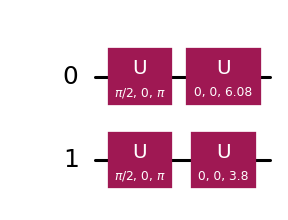

3q PCA | map=Pauli_r1_linear | qubits=3 | depth=12 | val_F1=0.86


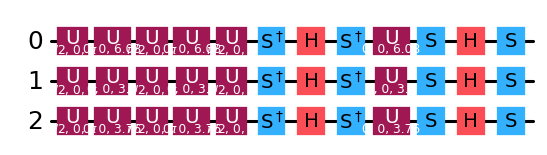

4q PCA | map=Pauli_r1_linear | qubits=4 | depth=12 | val_F1=0.88


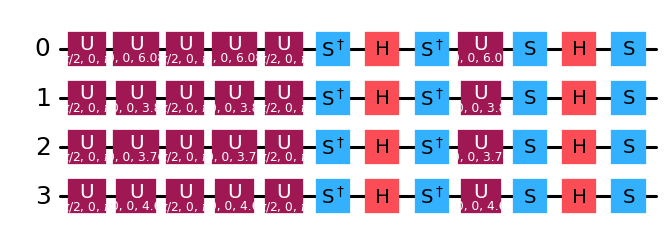

8q PCA | map=Z_r1 | qubits=8 | depth=2 | val_F1=0.90


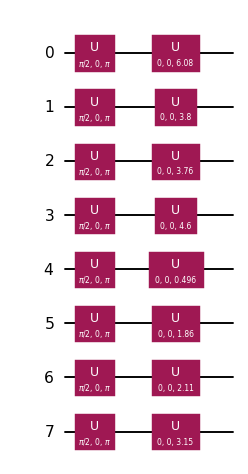

all features | map=Z_r1 | qubits=11 | depth=2 | val_F1=0.98


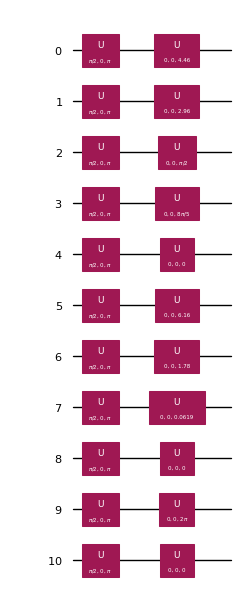

In [4]:
def make_feature_map(kind, n_qubits, reps, entanglement="linear"):
    if kind == "zz":
        return zz_feature_map(feature_dimension=n_qubits, reps=reps, entanglement=entanglement)
    if kind == "pauli":
        return pauli_feature_map(feature_dimension=n_qubits, reps=reps, entanglement=entanglement, paulis=["Z", "X", "Y"])
    if kind == "z":
        return z_feature_map(feature_dimension=n_qubits, reps=reps, entanglement=entanglement)
    raise ValueError(kind)


FEATURE_MAP_GRID = [
    {"name": "ZZ_r1_linear", "kind": "zz", "reps": 1, "entanglement": "linear"},
    {"name": "ZZ_r2_linear", "kind": "zz", "reps": 2, "entanglement": "linear"},
    {"name": "ZZ_r2_full", "kind": "zz", "reps": 2, "entanglement": "full"},
    {"name": "Pauli_r1_linear", "kind": "pauli", "reps": 1, "entanglement": "linear"},
    {"name": "Pauli_r2_linear", "kind": "pauli", "reps": 2, "entanglement": "linear"},
    {"name": "Z_r1", "kind": "z", "reps": 1, "entanglement": "linear"},
]


def transform_with_kappa(X, kappa):
    return np.asarray(X, dtype=float) * float(kappa)


def evaluate_kernel_matrix(q_kernel, X_rows, X_cols=None):
    if X_cols is None:
        return q_kernel.evaluate(x_vec=X_rows)
    return q_kernel.evaluate(x_vec=X_rows, y_vec=X_cols)


def pick_best_feature_map(case):
    rows = []
    for spec in FEATURE_MAP_GRID:
        fm = make_feature_map(spec["kind"], case.n_features, spec["reps"], spec["entanglement"])
        qk = FidelityStatevectorKernel(feature_map=fm, enforce_psd=True)
        X_tr = transform_with_kappa(case.X_train_q, 1.0)
        X_val = transform_with_kappa(case.X_val_q, 1.0)
        K_tr = evaluate_kernel_matrix(qk, X_tr)
        K_val = evaluate_kernel_matrix(qk, X_val, X_tr)
        m = SVC(kernel="precomputed", C=1.0, class_weight=QSVM_CLASS_WEIGHT)
        m.fit(K_tr, case.y_train)
        val_f1 = float(f1_score(case.y_val, m.predict(K_val), zero_division=0))
        rows.append({**spec, "val_f1": val_f1, "feature_map": fm})
    table = pd.DataFrame(rows).sort_values("val_f1", ascending=False)
    best = rows[int(table.index[0])]
    return best, table


def bind_fm(best, fm_name, qk_name):
    globals()[fm_name] = best["feature_map"]
    globals()[qk_name] = FidelityStatevectorKernel(feature_map=best["feature_map"], enforce_psd=True)


def draw_best_feature_map_circuit(case_obj, best, title):
    n = best["feature_map"].num_qubits
    qc = best["feature_map"].assign_parameters(case_obj.X_train_q[0]).decompose()
    scale = max(0.5, min(1.1, 5.5 / max(n, 1)))
    print(f"{title} | map={best['name']} | qubits={n} | depth={qc.depth()} | val_F1={best['val_f1']:.2f}")
    fig = qc.draw(output="mpl", fold=-1, idle_wires=False, scale=scale)
    if fig is not None:
        fig.set_size_inches(min(14, 1.6 * n + 2), min(8, 0.55 * n + 1.5))
        plt.close(fig)
        display(fig)


best_2, table_2 = pick_best_feature_map(case_2q)
best_3, table_3 = pick_best_feature_map(case_3q)
best_4, table_4 = pick_best_feature_map(case)
best_8, table_8 = pick_best_feature_map(case_8q)
best_all, table_all = pick_best_feature_map(case_all)
bind_fm(best_2, "feature_map_2q", "quantum_kernel_2q")
bind_fm(best_3, "feature_map_3q", "quantum_kernel_3q")
bind_fm(best_4, "feature_map", "quantum_kernel")
bind_fm(best_8, "feature_map_8q", "quantum_kernel_8q")
bind_fm(best_all, "feature_map_all", "quantum_kernel_all")
print("Selected maps:", best_2["name"], best_3["name"], best_4["name"], best_8["name"], best_all["name"])

for label, c, b in [
    ("2q PCA", case_2q, best_2),
    ("3q PCA", case_3q, best_3),
    ("4q PCA", case, best_4),
    ("8q PCA", case_8q, best_8),
    ("all features", case_all, best_all),
]:
    draw_best_feature_map_circuit(c, b, label)


In [5]:
def tune_qsvm_on_validation(q_kernel, case, kappa_grid, c_grid):
    rows = []
    for kappa in kappa_grid:
        X_train_k = transform_with_kappa(case.X_train_q, kappa)
        X_val_k = transform_with_kappa(case.X_val_q, kappa)
        K_tr = evaluate_kernel_matrix(q_kernel, X_train_k)
        K_val = evaluate_kernel_matrix(q_kernel, X_val_k, X_train_k)
        for C in c_grid:
            m = SVC(kernel="precomputed", C=C, class_weight=QSVM_CLASS_WEIGHT)
            m.fit(K_tr, case.y_train)
            val_f1 = float(f1_score(case.y_val, m.predict(K_val), zero_division=0))
            rows.append({"kappa": float(kappa), "C": float(C), "val_f1": val_f1})
    tune_df = pd.DataFrame(rows)
    best = tune_df.loc[tune_df["val_f1"].idxmax()]
    return float(best["kappa"]), float(best["C"]), tune_df


def fit_qsvm_precomputed(K_train, y_train, K_eval_dict, C=1.0):
    model = SVC(kernel="precomputed", C=C, class_weight=QSVM_CLASS_WEIGHT, probability=True)
    model.fit(K_train, y_train)
    out = {"model": model}
    for name, K in K_eval_dict.items():
        out[name] = {"y_pred": model.predict(K), "y_score": model.predict_proba(K)[:, 1]}
    return out


def metric_row(model_name, split_name, y_true, y_pred, y_score=None):
    row = {"model": model_name, "split": split_name,
           "accuracy": float(accuracy_score(y_true, y_pred)),
           "f1": float(f1_score(y_true, y_pred, zero_division=0)), "roc_auc": None}
    if y_score is not None and len(np.unique(y_true)) > 1:
        row["roc_auc"] = float(roc_auc_score(y_true, y_score))
    return row


BEST_KAPPA_2Q, BEST_C_2Q, tune_df_2q = tune_qsvm_on_validation(quantum_kernel_2q, case_2q, KAPPA_GRID, C_GRID)
BEST_KAPPA_3Q, BEST_C_3Q, tune_df_3q = tune_qsvm_on_validation(quantum_kernel_3q, case_3q, KAPPA_GRID, C_GRID)
BEST_KAPPA, BEST_C, tune_df = tune_qsvm_on_validation(quantum_kernel, case, KAPPA_GRID, C_GRID)
BEST_KAPPA_8Q, BEST_C_8Q, tune_df_8q = tune_qsvm_on_validation(quantum_kernel_8q, case_8q, KAPPA_GRID, C_GRID)
BEST_KAPPA_ALL, BEST_C_ALL, tune_df_all = tune_qsvm_on_validation(quantum_kernel_all, case_all, KAPPA_GRID, C_GRID)

def _rbf_gamma_sort_key(gamma):
    if gamma == "scale":
        return 50.0
    if gamma == "auto":
        return 51.0
    return float(gamma)


def pick_best_rbf_row(df_tune):
    """Among max validation F1 ties, prefer smaller γ (local kernel), then val accuracy, then smaller C."""
    max_f1 = df_tune["val_f1"].max()
    top = df_tune[df_tune["val_f1"] >= max_f1 - 1e-12].copy()
    if len(top) == 1:
        return top.iloc[0]
    top["_gamma_key"] = top["gamma"].map(_rbf_gamma_sort_key)
    return top.sort_values(["_gamma_key", "val_acc", "C"], ascending=[True, False, True]).iloc[0]


def tune_rbf(case, c_grid, gamma_grid, class_weight):
    rows = []
    for gamma in gamma_grid:
        for C in c_grid:
            m = SVC(kernel="rbf", C=C, gamma=gamma, class_weight=class_weight)
            m.fit(case.X_train_feat, case.y_train)
            pred = m.predict(case.X_val_feat)
            rows.append({
                "C": float(C),
                "gamma": gamma,
                "val_f1": float(f1_score(case.y_val, pred, zero_division=0)),
                "val_acc": float(accuracy_score(case.y_val, pred)),
            })
    df_tune = pd.DataFrame(rows).sort_values("val_f1", ascending=False)
    return pick_best_rbf_row(df_tune), df_tune


def rbf_gamma_arg(gamma):
    return gamma if gamma in ("scale", "auto") else float(gamma)


def make_rbf_svc(best_row):
    return SVC(
        kernel="rbf",
        C=float(best_row["C"]),
        gamma=rbf_gamma_arg(best_row["gamma"]),
        class_weight=RBF_CLASS_WEIGHT,
        probability=True,
    )


best_rbf_2, tune_rbf_df_2 = tune_rbf(case_2q, RBF_C_GRID, GAMMA_GRID, RBF_CLASS_WEIGHT)
best_rbf_3, tune_rbf_df_3 = tune_rbf(case_3q, RBF_C_GRID, GAMMA_GRID, RBF_CLASS_WEIGHT)
best_rbf_4, tune_rbf_df_4 = tune_rbf(case, RBF_C_GRID, GAMMA_GRID, RBF_CLASS_WEIGHT)
best_rbf_8, tune_rbf_df_8 = tune_rbf(case_8q, RBF_C_GRID, GAMMA_GRID, RBF_CLASS_WEIGHT)
best_rbf_all, tune_rbf_df_all = tune_rbf(case_all, RBF_C_GRID, GAMMA_GRID, RBF_CLASS_WEIGHT)


def show_rbf_tune(label, best_row, tune_df, n_top=5):
    """Top validation-F1 points from the RBF C × γ grid (same metric used for selection)."""
    print(
        f"\nRBF [{label}] — best val F1={best_row['val_f1']:.4f} "
        f"(C={best_row['C']:.4g}, γ={best_row['gamma']}, val_acc={best_row['val_acc']:.4f})"
    )
    display(tune_df[["gamma", "C", "val_f1", "val_acc"]].head(n_top).reset_index(drop=True))


for _lbl, _best, _df in [
    ("2pca", best_rbf_2, tune_rbf_df_2),
    ("3pca", best_rbf_3, tune_rbf_df_3),
    ("4pca", best_rbf_4, tune_rbf_df_4),
    ("8pca", best_rbf_8, tune_rbf_df_8),
    (f"{case_all.n_features}f", best_rbf_all, tune_rbf_df_all),
]:
    show_rbf_tune(_lbl, _best, _df)

BEST_C_RBF_2 = float(best_rbf_2["C"])
BEST_GAMMA_RBF_2 = best_rbf_2["gamma"]
BEST_C_RBF_3 = float(best_rbf_3["C"])
BEST_GAMMA_RBF_3 = best_rbf_3["gamma"]
BEST_C_RBF_4 = float(best_rbf_4["C"])
BEST_GAMMA_RBF_4 = best_rbf_4["gamma"]
BEST_C_RBF_8 = float(best_rbf_8["C"])
BEST_GAMMA_RBF_8 = best_rbf_8["gamma"]
BEST_C_CLF_ALL = float(best_rbf_all["C"])
BEST_GAMMA_CLF_ALL = best_rbf_all["gamma"]
print(
    f"QSVM κ/C: 2q=({BEST_KAPPA_2Q:.2f},{BEST_C_2Q:.3g}) 3q=({BEST_KAPPA_3Q:.2f},{BEST_C_3Q:.3g}) "
    f"4q=({BEST_KAPPA:.2f},{BEST_C:.3g}) 8q=({BEST_KAPPA_8Q:.2f},{BEST_C_8Q:.3g}) "
    f"all=({BEST_KAPPA_ALL:.2f},{BEST_C_ALL:.3g})"
)
print(
    f"RBF: 2pca C={BEST_C_RBF_2:.3g} γ={BEST_GAMMA_RBF_2} | "
    f"3pca C={BEST_C_RBF_3:.3g} γ={BEST_GAMMA_RBF_3} | "
    f"4pca C={BEST_C_RBF_4:.3g} γ={BEST_GAMMA_RBF_4} | "
    f"8pca C={BEST_C_RBF_8:.3g} γ={BEST_GAMMA_RBF_8} | "
    f"11f C={BEST_C_CLF_ALL:.3g} γ={BEST_GAMMA_CLF_ALL}"
)



RBF [2pca] — best val F1=0.8529 (C=15.85, γ=0.001, val_acc=0.8592)


,gamma,C,val_f1,val_acc
0,0.001,15.848932,0.852941,0.859155
1,0.03,4.641589,0.852941,0.859155
2,0.1,0.735642,0.852941,0.859155
3,0.001,54.116953,0.852941,0.859155
4,0.001,100.000000,0.852941,0.859155



RBF [3pca] — best val F1=0.9524 (C=0.7356, γ=0.005, val_acc=0.9577)


,gamma,C,val_f1,val_acc
0,0.005,0.735642,0.952381,0.957746
1,0.03,0.116591,0.952381,0.957746
2,0.15,0.034145,0.952381,0.957746
3,0.02,0.215443,0.952381,0.957746
4,0.01,0.398107,0.952381,0.957746



RBF [4pca] — best val F1=0.9524 (C=0.7356, γ=0.005, val_acc=0.9577)


...


RBF [8pca] — best val F1=0.9836 (C=4.642, γ=0.001, val_acc=0.9859)


,gamma,C,val_f1,val_acc
0,0.1,1.359356,0.983607,0.985915
1,0.075,4.641589,0.983607,0.985915
2,0.05,4.641589,0.983607,0.985915
3,0.05,8.576959,0.983607,0.985915
4,0.05,15.848932,0.983607,0.985915



RBF [11f] — best val F1=0.9836 (C=2.512, γ=0.001, val_acc=0.9859)


,gamma,C,val_f1,val_acc
0,0.1,1.359356,0.983607,0.985915
1,0.03,4.641589,0.983607,0.985915
2,0.02,54.116953,0.983607,0.985915
3,0.02,100.000000,0.983607,0.985915
4,0.03,0.398107,0.983607,0.985915


QSVM κ/C: 2q=(0.25,5.96) 3q=(0.50,0.708) 4q=(0.50,0.0841) 8q=(0.25,0.244) all=(0.25,2.05)
RBF: 2pca C=15.8 γ=0.001 | 3pca C=0.736 γ=0.005 | 4pca C=0.736 γ=0.005 | 8pca C=4.64 γ=0.001 | 11f C=2.51 γ=0.001


In [6]:
def fit_sklearn(model, X_train, y_train, X_eval):
    model.fit(X_train, y_train)
    out = {"model": model}
    for name, Xs in X_eval.items():
        out[name] = {"y_pred": model.predict(Xs), "y_score": model.predict_proba(Xs)[:, 1]}
    return out


def fit_rbf_branch(case_obj, best_row):
    X_eval = {"val": case_obj.X_val_feat, "test": case_obj.X_test_feat}
    return fit_sklearn(make_rbf_svc(best_row), case_obj.X_train_feat, case_obj.y_train, X_eval)


svc_rbf_2 = fit_rbf_branch(case_2q, best_rbf_2)
svc_rbf_3 = fit_rbf_branch(case_3q, best_rbf_3)
svc_rbf_4 = fit_rbf_branch(case, best_rbf_4)
svc_rbf_8 = fit_rbf_branch(case_8q, best_rbf_8)
svc_rbf = fit_rbf_branch(case_all, best_rbf_all)  # 11-feature baseline

X_train_2q = transform_with_kappa(case_2q.X_train_q, BEST_KAPPA_2Q)
X_val_2q = transform_with_kappa(case_2q.X_val_q, BEST_KAPPA_2Q)
X_test_2q = transform_with_kappa(case_2q.X_test_q, BEST_KAPPA_2Q)
K_train_2q = evaluate_kernel_matrix(quantum_kernel_2q, X_train_2q)
K_val_2q = evaluate_kernel_matrix(quantum_kernel_2q, X_val_2q, X_train_2q)
K_test_2q = evaluate_kernel_matrix(quantum_kernel_2q, X_test_2q, X_train_2q)
qsvm_2q_tuned = fit_qsvm_precomputed(K_train_2q, case_2q.y_train, {"val": K_val_2q, "test": K_test_2q}, C=BEST_C_2Q)

X_train_3q = transform_with_kappa(case_3q.X_train_q, BEST_KAPPA_3Q)
X_val_3q = transform_with_kappa(case_3q.X_val_q, BEST_KAPPA_3Q)
X_test_3q = transform_with_kappa(case_3q.X_test_q, BEST_KAPPA_3Q)
K_train_3q = evaluate_kernel_matrix(quantum_kernel_3q, X_train_3q)
K_val_3q = evaluate_kernel_matrix(quantum_kernel_3q, X_val_3q, X_train_3q)
K_test_3q = evaluate_kernel_matrix(quantum_kernel_3q, X_test_3q, X_train_3q)
qsvm_3q_tuned = fit_qsvm_precomputed(K_train_3q, case_3q.y_train, {"val": K_val_3q, "test": K_test_3q}, C=BEST_C_3Q)

X_train_best = transform_with_kappa(case.X_train_q, BEST_KAPPA)
X_val_best = transform_with_kappa(case.X_val_q, BEST_KAPPA)
X_test_best = transform_with_kappa(case.X_test_q, BEST_KAPPA)
K_train_best = evaluate_kernel_matrix(quantum_kernel, X_train_best)
K_val_best = evaluate_kernel_matrix(quantum_kernel, X_val_best, X_train_best)
K_test_best = evaluate_kernel_matrix(quantum_kernel, X_test_best, X_train_best)
qsvm_tuned = fit_qsvm_precomputed(K_train_best, case.y_train, {"val": K_val_best, "test": K_test_best}, C=BEST_C)

X_train_8q = transform_with_kappa(case_8q.X_train_q, BEST_KAPPA_8Q)
X_val_8q = transform_with_kappa(case_8q.X_val_q, BEST_KAPPA_8Q)
X_test_8q = transform_with_kappa(case_8q.X_test_q, BEST_KAPPA_8Q)
K_train_8q = evaluate_kernel_matrix(quantum_kernel_8q, X_train_8q)
K_val_8q = evaluate_kernel_matrix(quantum_kernel_8q, X_val_8q, X_train_8q)
K_test_8q = evaluate_kernel_matrix(quantum_kernel_8q, X_test_8q, X_train_8q)
qsvm_8q_tuned = fit_qsvm_precomputed(K_train_8q, case_8q.y_train, {"val": K_val_8q, "test": K_test_8q}, C=BEST_C_8Q)

X_train_all = transform_with_kappa(case_all.X_train_q, BEST_KAPPA_ALL)
X_val_all = transform_with_kappa(case_all.X_val_q, BEST_KAPPA_ALL)
X_test_all = transform_with_kappa(case_all.X_test_q, BEST_KAPPA_ALL)
K_train_all = evaluate_kernel_matrix(quantum_kernel_all, X_train_all)
K_val_all = evaluate_kernel_matrix(quantum_kernel_all, X_val_all, X_train_all)
K_test_all = evaluate_kernel_matrix(quantum_kernel_all, X_test_all, X_train_all)
qsvm_all_tuned = fit_qsvm_precomputed(K_train_all, case_all.y_train, {"val": K_val_all, "test": K_test_all}, C=BEST_C_ALL)

metric_rows = []
for name, trained, yv, yt in [
    ("qsvm_2q", qsvm_2q_tuned, case_2q.y_val, case_2q.y_test),
    ("qsvm_3q", qsvm_3q_tuned, case_3q.y_val, case_3q.y_test),
    ("qsvm_4q", qsvm_tuned, case.y_val, case.y_test),
    ("qsvm_8q", qsvm_8q_tuned, case_8q.y_val, case_8q.y_test),
    ("qsvm_all", qsvm_all_tuned, case_all.y_val, case_all.y_test),
    ("rbf_2pca", svc_rbf_2, case_2q.y_val, case_2q.y_test),
    ("rbf_3pca", svc_rbf_3, case_3q.y_val, case_3q.y_test),
    ("rbf_4pca", svc_rbf_4, case.y_val, case.y_test),
    ("rbf_8pca", svc_rbf_8, case_8q.y_val, case_8q.y_test),
    (f"rbf_{case_all.n_features}f", svc_rbf, case_all.y_val, case_all.y_test),
]:
    for split, y_true in [("val", yv), ("test", yt)]:
        s = trained[split]
        metric_rows.append(metric_row(name, split, y_true, s["y_pred"], s["y_score"]))
display(pd.DataFrame(metric_rows))


,model,split,accuracy,f1,roc_auc
0,qsvm_2q,val,0.859155,0.852941,0.937398
1,qsvm_2q,test,0.844828,0.790698,0.950311
2,qsvm_3q,val,0.929577,0.923077,0.988618
3,qsvm_3q,test,0.862069,0.818182,0.950311
4,qsvm_4q,val,0.943662,0.933333,0.989431
5,qsvm_4q,test,0.844828,0.769231,0.941615
6,qsvm_8q,val,0.985915,0.983607,0.997561
7,qsvm_8q,test,0.931034,0.904762,0.995031
8,qsvm_all,val,0.985915,0.983607,1.000000
9,qsvm_all,test,1.000000,1.000000,1.000000


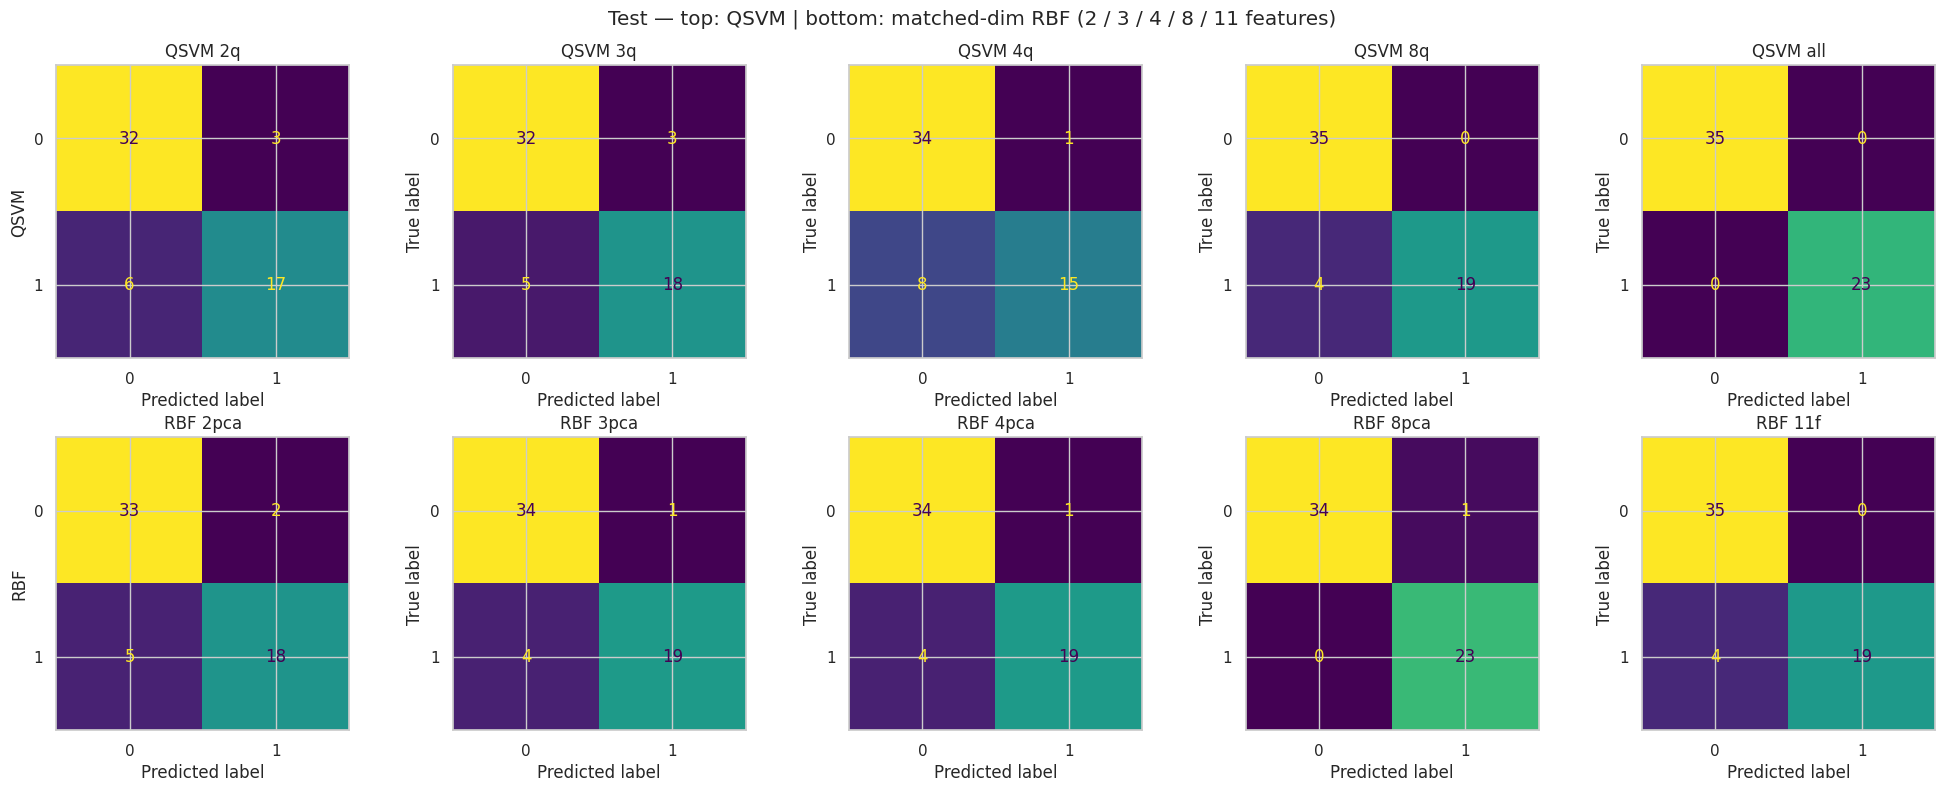

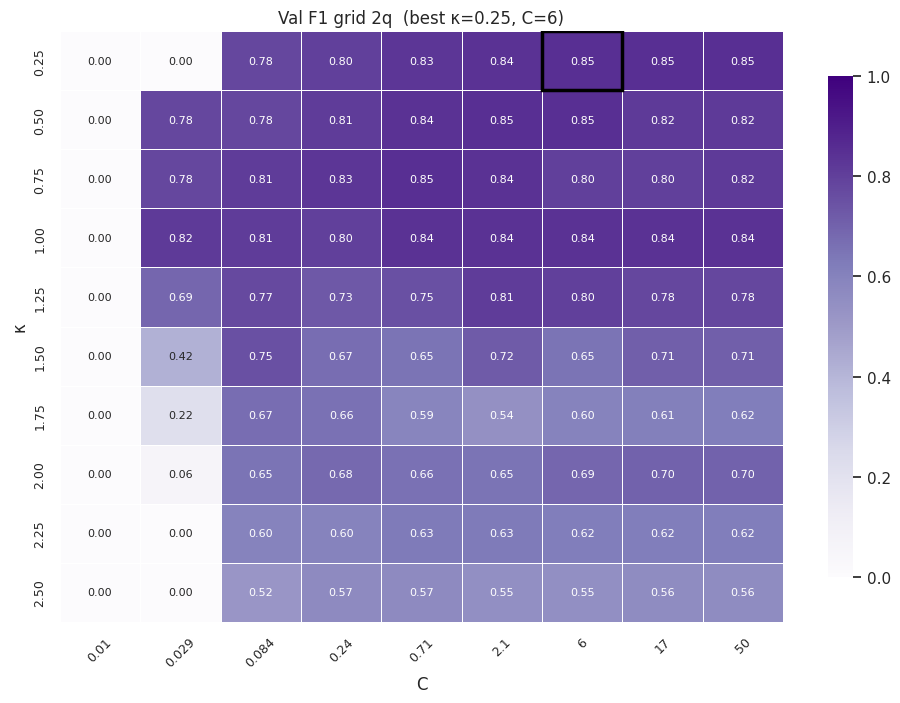

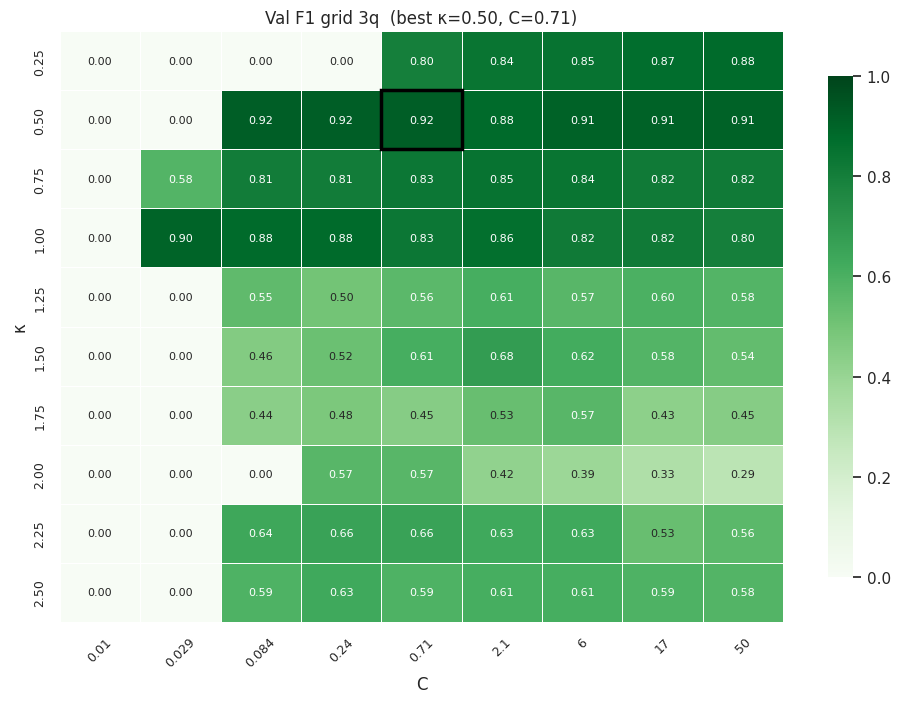

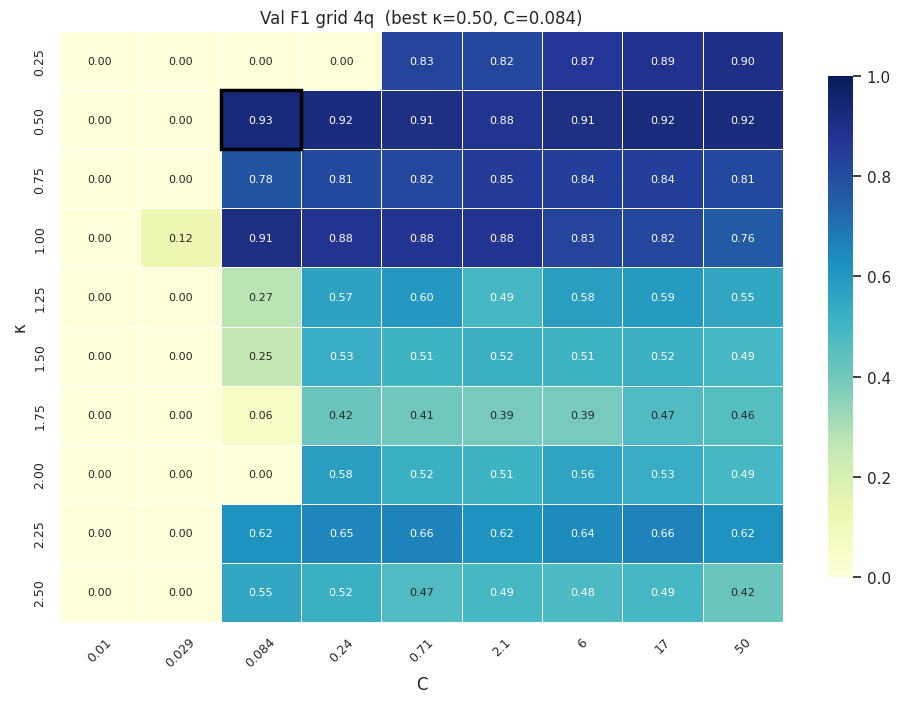

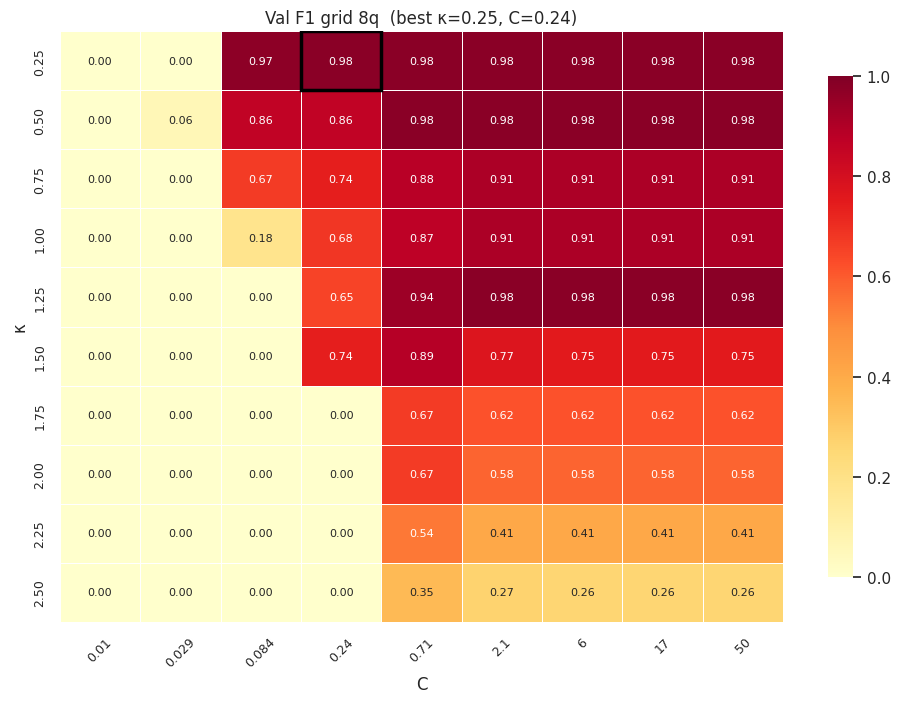

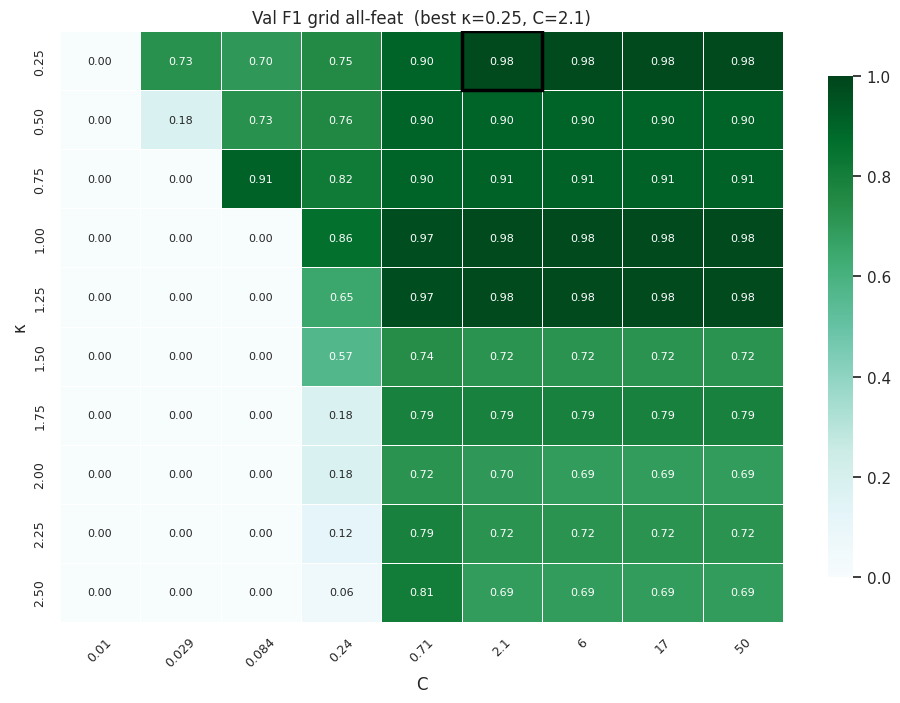

In [7]:

def _tune_pivot_for_heatmap(tune_df):
    """Pivot κ × C with stable, readable axis labels."""
    df = tune_df.copy()
    df["kappa"] = np.round(df["kappa"].astype(float), 4)
    df["C"] = df["C"].astype(float)
    pivot = df.pivot(index="kappa", columns="C", values="val_f1")
    pivot.index = [f"{k:.2f}" for k in pivot.index]
    pivot.columns = [f"{c:.2g}" for c in pivot.columns]
    return pivot


def plot_tune_heatmap(tune_df, title, best_kappa, best_C, cmap="YlGnBu"):
    pivot = _tune_pivot_for_heatmap(tune_df).round(2)
    n_k, n_c = pivot.shape
    fig, ax = plt.subplots(figsize=(max(9.0, 0.6 * n_c + 4.5), max(5.5, 0.52 * n_k + 2.0)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        ax=ax,
        vmin=0,
        vmax=1,
        linewidths=0.4,
        linecolor="white",
        annot_kws={"size": 8},
        cbar_kws={"shrink": 0.85},
    )
    k_lbl, c_lbl = f"{float(best_kappa):.2f}", f"{float(best_C):.2g}"
    if k_lbl in pivot.index and c_lbl in pivot.columns:
        i, j = list(pivot.index).index(k_lbl), list(pivot.columns).index(c_lbl)
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="black", lw=2.5))
    ax.set_title(f"{title}  (best κ={k_lbl}, C={c_lbl})")
    ax.set_xlabel("C")
    ax.set_ylabel("κ")
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    plt.subplots_adjust(left=0.16, bottom=0.22)
    plt.tight_layout()
    plt.show()


fig, axes = plt.subplots(2, 5, figsize=(20, 8))
qsvm_cm = [
    ("QSVM 2q", qsvm_2q_tuned, case_2q.y_test),
    ("QSVM 3q", qsvm_3q_tuned, case_3q.y_test),
    ("QSVM 4q", qsvm_tuned, case.y_test),
    ("QSVM 8q", qsvm_8q_tuned, case_8q.y_test),
    ("QSVM all", qsvm_all_tuned, case_all.y_test),
]
rbf_cm = [
    ("RBF 2pca", svc_rbf_2, case_2q.y_test),
    ("RBF 3pca", svc_rbf_3, case_3q.y_test),
    ("RBF 4pca", svc_rbf_4, case.y_test),
    ("RBF 8pca", svc_rbf_8, case_8q.y_test),
    (f"RBF {case_all.n_features}f", svc_rbf, case_all.y_test),
]
for col, (title, trained, y_test) in enumerate(qsvm_cm):
    ConfusionMatrixDisplay.from_predictions(y_test, trained["test"]["y_pred"], ax=axes[0, col], colorbar=False)
    axes[0, col].set_title(title)
for col, (title, trained, y_test) in enumerate(rbf_cm):
    ConfusionMatrixDisplay.from_predictions(y_test, trained["test"]["y_pred"], ax=axes[1, col], colorbar=False)
    axes[1, col].set_title(title)
axes[0, 0].set_ylabel("QSVM")
axes[1, 0].set_ylabel("RBF")
fig.suptitle("Test — top: QSVM | bottom: matched-dim RBF (2 / 3 / 4 / 8 / 11 features)")
plt.tight_layout()
plt.show()

plot_tune_heatmap(tune_df_2q, "Val F1 grid 2q", BEST_KAPPA_2Q, BEST_C_2Q, cmap="Purples")
plot_tune_heatmap(tune_df_3q, "Val F1 grid 3q", BEST_KAPPA_3Q, BEST_C_3Q, cmap="Greens")
plot_tune_heatmap(tune_df, "Val F1 grid 4q", BEST_KAPPA, BEST_C)
plot_tune_heatmap(tune_df_8q, "Val F1 grid 8q", BEST_KAPPA_8Q, BEST_C_8Q, cmap="YlOrRd")
plot_tune_heatmap(tune_df_all, "Val F1 grid all-feat", BEST_KAPPA_ALL, BEST_C_ALL, cmap="BuGn")


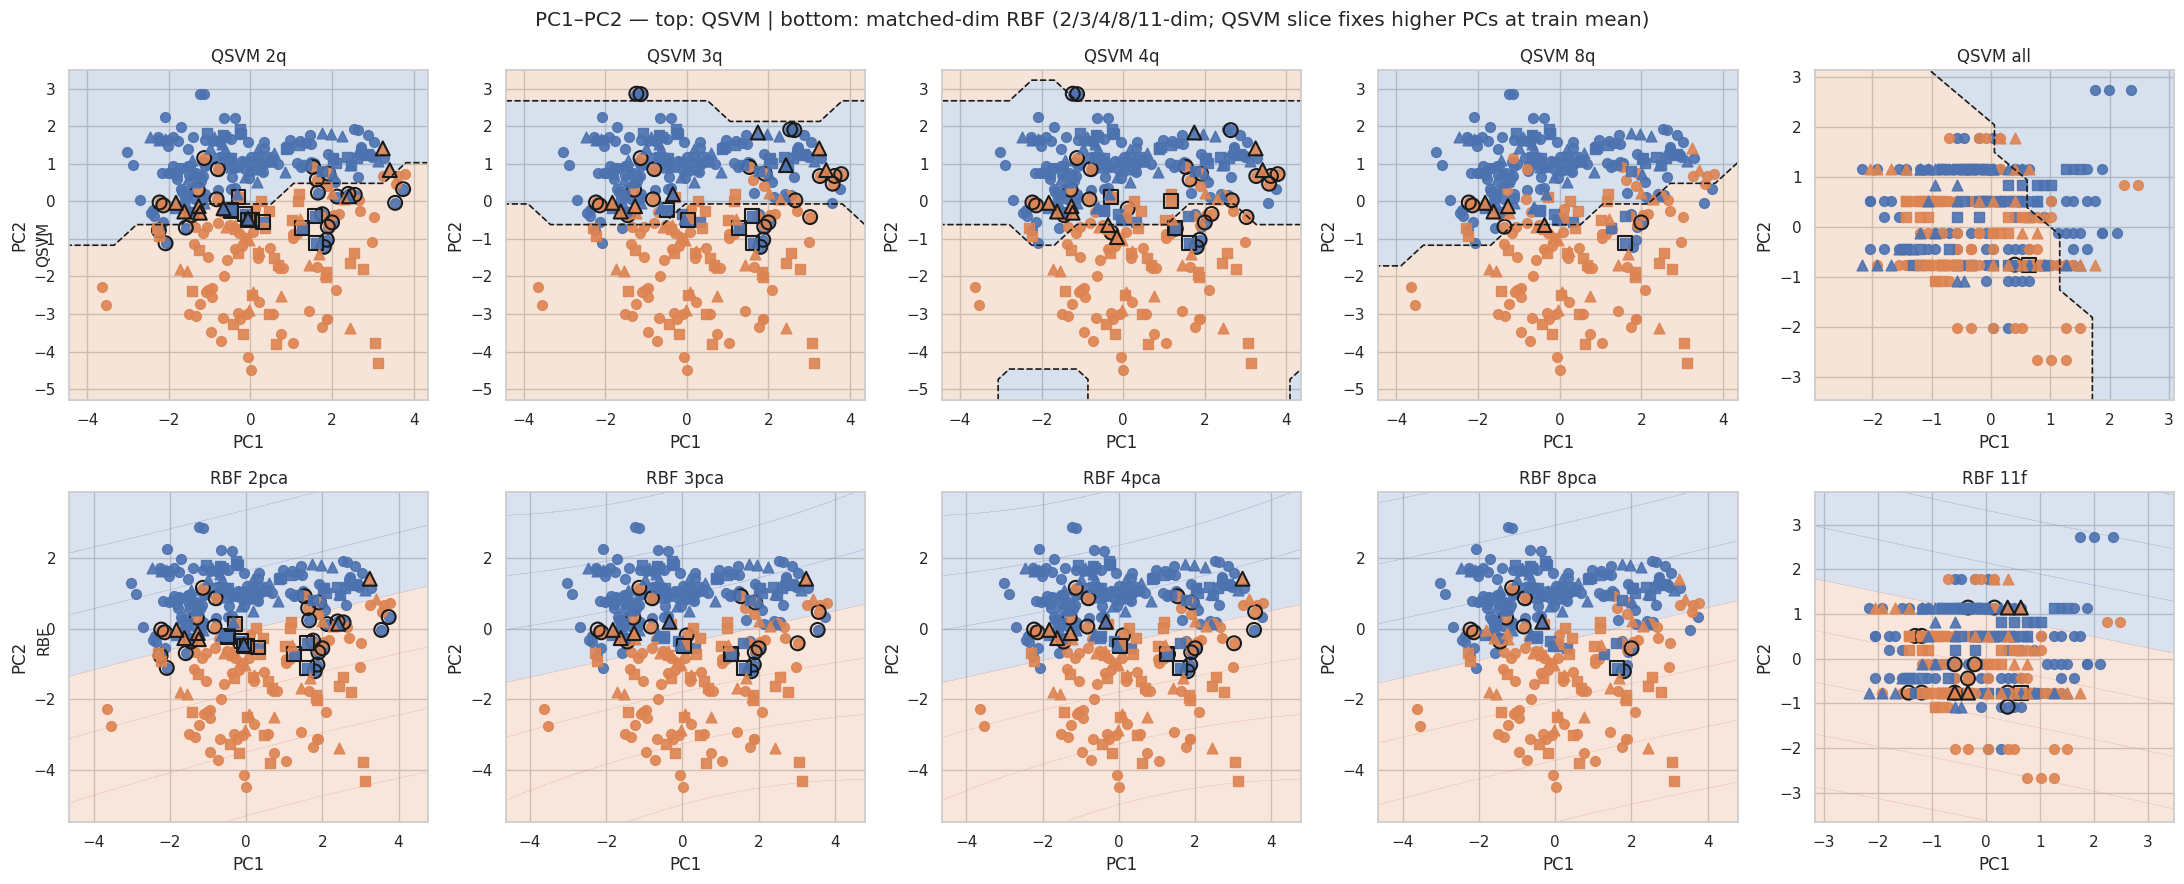

saved /workspaces/QML/hackathon/challenge-02-dementia-classifier/results/metrics_2q3q.json


In [8]:
def stack_case_for_plot(case, preds_by_split):
    rows = []
    for split in ("train", "val", "test"):
        Xp = getattr(case, f"X_{split}_pca")[:, :2]
        y_true = getattr(case, f"y_{split}")
        y_pred = preds_by_split[split]
        for i in range(len(y_true)):
            rows.append({"pc1": Xp[i, 0], "pc2": Xp[i, 1], "y_true": int(y_true[i]), "y_pred": int(y_pred[i]), "split": split})
    return pd.DataFrame(rows)


def plot_boundary_qsvm_2d(ax, case, q_kernel, kappa, C, angle_scaler):
    X_all = np.vstack([case.X_train_pca, case.X_val_pca, case.X_test_pca])[:, :2]
    pad = 0.8
    x_min, x_max = X_all[:, 0].min() - pad, X_all[:, 0].max() + pad
    y_min, y_max = X_all[:, 1].min() - pad, X_all[:, 1].max() + pad
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.55), np.arange(y_min, y_max, 0.55))
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    train_pca = case.X_train_pca
    if train_pca.shape[1] > 2:
        grid_full = np.hstack([grid_2d, np.tile(train_pca[:, 2:].mean(axis=0), (len(grid_2d), 1))])
    else:
        grid_full = grid_2d
    X_train_q = np.clip(angle_scaler.transform(train_pca) * kappa, 0, np.pi)
    grid_q = np.clip(angle_scaler.transform(grid_full) * kappa, 0, np.pi)
    K_train = evaluate_kernel_matrix(q_kernel, X_train_q)
    K_grid = evaluate_kernel_matrix(q_kernel, grid_q, X_train_q)
    svc = SVC(kernel="precomputed", C=C, class_weight=QSVM_CLASS_WEIGHT).fit(K_train, case.y_train)
    zz = svc.predict(K_grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=[CLASS_COLORS[0], CLASS_COLORS[1]], alpha=0.22)
    ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=1.2, linestyles="--")


def scatter_classified(ax, plot_df, title):
    for split, marker in SPLIT_MARKERS.items():
        sub = plot_df[plot_df["split"] == split]
        for label in (0, 1):
            m = sub[sub["y_true"] == label]
            ax.scatter(m["pc1"], m["pc2"], c=CLASS_COLORS[label], marker=marker, s=50 if split != "test" else 60, alpha=0.9)
        wrong = sub[sub["y_true"] != sub["y_pred"]]
        if len(wrong):
            ax.scatter(wrong["pc1"], wrong["pc2"], facecolors="none", edgecolors="k", s=100, linewidths=1.5, marker=marker)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")


angle_2q = MinMaxScaler((0, np.pi)).fit(case_2q.X_train_pca)
angle_3q = MinMaxScaler((0, np.pi)).fit(case_3q.X_train_pca)
angle_4q = MinMaxScaler((0, np.pi)).fit(case.X_train_pca)
angle_8q = MinMaxScaler((0, np.pi)).fit(case_8q.X_train_pca)
angle_all = MinMaxScaler((0, np.pi)).fit(case_all.X_train_feat)

preds_2q = {"train": qsvm_2q_tuned["model"].predict(K_train_2q), "val": qsvm_2q_tuned["val"]["y_pred"], "test": qsvm_2q_tuned["test"]["y_pred"]}
preds_3q = {"train": qsvm_3q_tuned["model"].predict(K_train_3q), "val": qsvm_3q_tuned["val"]["y_pred"], "test": qsvm_3q_tuned["test"]["y_pred"]}
preds_4q = {"train": qsvm_tuned["model"].predict(K_train_best), "val": qsvm_tuned["val"]["y_pred"], "test": qsvm_tuned["test"]["y_pred"]}
preds_8q = {"train": qsvm_8q_tuned["model"].predict(K_train_8q), "val": qsvm_8q_tuned["val"]["y_pred"], "test": qsvm_8q_tuned["test"]["y_pred"]}
preds_all = {"train": qsvm_all_tuned["model"].predict(K_train_all), "val": qsvm_all_tuned["val"]["y_pred"], "test": qsvm_all_tuned["test"]["y_pred"]}
preds_rbf_2 = {"train": svc_rbf_2["model"].predict(case_2q.X_train_feat), "val": svc_rbf_2["val"]["y_pred"], "test": svc_rbf_2["test"]["y_pred"]}
preds_rbf_3 = {"train": svc_rbf_3["model"].predict(case_3q.X_train_feat), "val": svc_rbf_3["val"]["y_pred"], "test": svc_rbf_3["test"]["y_pred"]}
preds_rbf_4 = {"train": svc_rbf_4["model"].predict(case.X_train_feat), "val": svc_rbf_4["val"]["y_pred"], "test": svc_rbf_4["test"]["y_pred"]}
preds_rbf_8 = {"train": svc_rbf_8["model"].predict(case_8q.X_train_feat), "val": svc_rbf_8["val"]["y_pred"], "test": svc_rbf_8["test"]["y_pred"]}
preds_clf = {"train": svc_rbf["model"].predict(case_all.X_train_feat), "val": svc_rbf["val"]["y_pred"], "test": svc_rbf["test"]["y_pred"]}


def plot_boundary_rbf_2d(ax, case_obj, best_row):
    est = make_rbf_svc(best_row).fit(case_obj.X_train_feat[:, :2], case_obj.y_train)
    DecisionBoundaryDisplay.from_estimator(
        est,
        case_obj.X_train_feat[:, :2],
        ax=ax,
        cmap=ListedColormap([CLASS_COLORS[0], CLASS_COLORS[1]]),
        alpha=0.2,
        grid_resolution=60,
    )


qsvm_panels = [
    (case_2q, preds_2q, "QSVM 2q", "2q"),
    (case_3q, preds_3q, "QSVM 3q", "3q"),
    (case, preds_4q, "QSVM 4q", "4q"),
    (case_8q, preds_8q, "QSVM 8q", "8q"),
    (case_all, preds_all, "QSVM all", "allq"),
]
rbf_panels = [
    (case_2q, preds_rbf_2, "RBF 2pca", "rbf2"),
    (case_3q, preds_rbf_3, "RBF 3pca", "rbf3"),
    (case, preds_rbf_4, "RBF 4pca", "rbf4"),
    (case_8q, preds_rbf_8, "RBF 8pca", "rbf8"),
    (case_all, preds_clf, f"RBF {case_all.n_features}f", "rbfall"),
]
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for col, (case_obj, preds, title, mode) in enumerate(qsvm_panels):
    ax = axes[0, col]
    if mode == "2q":
        plot_boundary_qsvm_2d(ax, case_obj, quantum_kernel_2q, BEST_KAPPA_2Q, BEST_C_2Q, angle_2q)
    elif mode == "3q":
        plot_boundary_qsvm_2d(ax, case_obj, quantum_kernel_3q, BEST_KAPPA_3Q, BEST_C_3Q, angle_3q)
    elif mode == "4q":
        plot_boundary_qsvm_2d(ax, case_obj, quantum_kernel, BEST_KAPPA, BEST_C, angle_4q)
    elif mode == "8q":
        plot_boundary_qsvm_2d(ax, case_obj, quantum_kernel_8q, BEST_KAPPA_8Q, BEST_C_8Q, angle_8q)
    else:
        plot_boundary_qsvm_2d(ax, case_obj, quantum_kernel_all, BEST_KAPPA_ALL, BEST_C_ALL, angle_all)
    scatter_classified(ax, stack_case_for_plot(case_obj, preds), title)
for col, (case_obj, preds, title, _mode) in enumerate(rbf_panels):
    ax = axes[1, col]
    best_row = (best_rbf_2, best_rbf_3, best_rbf_4, best_rbf_8, best_rbf_all)[col]
    plot_boundary_rbf_2d(ax, case_obj, best_row)
    scatter_classified(ax, stack_case_for_plot(case_obj, preds), title)
fig.text(0.02, 0.72, "QSVM", rotation=90, va="center", fontsize=11)
fig.text(0.02, 0.28, "RBF", rotation=90, va="center", fontsize=11)
fig.suptitle("PC1–PC2 — top: QSVM | bottom: matched-dim RBF (2/3/4/8/11-dim; QSVM slice fixes higher PCs at train mean)")
plt.tight_layout()
plt.show()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / "metrics_2q3q.json", "w") as f:
    json.dump({"data_source": DATA_SOURCE, "metrics": metric_rows,
               "best_2q": {"kappa": BEST_KAPPA_2Q, "C": BEST_C_2Q, "fm": best_2["name"]},
               "best_3q": {"kappa": BEST_KAPPA_3Q, "C": BEST_C_3Q, "fm": best_3["name"]},
"best_4q": {"kappa": BEST_KAPPA, "C": BEST_C, "fm": best_4["name"]},
               "best_8q": {"kappa": BEST_KAPPA_8Q, "C": BEST_C_8Q, "fm": best_8["name"]},
               "best_all": {"kappa": BEST_KAPPA_ALL, "C": BEST_C_ALL, "fm": best_all["name"]},
               "best_rbf_2pca": {"C": BEST_C_RBF_2,
                                 "gamma": BEST_GAMMA_RBF_2 if isinstance(BEST_GAMMA_RBF_2, str) else float(BEST_GAMMA_RBF_2),
                                 "class_weight": RBF_CLASS_WEIGHT},
               "best_rbf_3pca": {"C": BEST_C_RBF_3,
                                 "gamma": BEST_GAMMA_RBF_3 if isinstance(BEST_GAMMA_RBF_3, str) else float(BEST_GAMMA_RBF_3),
                                 "class_weight": RBF_CLASS_WEIGHT},
               "best_rbf_4pca": {"C": BEST_C_RBF_4,
                                 "gamma": BEST_GAMMA_RBF_4 if isinstance(BEST_GAMMA_RBF_4, str) else float(BEST_GAMMA_RBF_4),
                                 "class_weight": RBF_CLASS_WEIGHT},
               "best_rbf_8pca": {"C": BEST_C_RBF_8,
                                 "gamma": BEST_GAMMA_RBF_8 if isinstance(BEST_GAMMA_RBF_8, str) else float(BEST_GAMMA_RBF_8),
                                 "class_weight": RBF_CLASS_WEIGHT},
               "best_rbf_11f": {"C": BEST_C_CLF_ALL,
                                "gamma": BEST_GAMMA_CLF_ALL if isinstance(BEST_GAMMA_CLF_ALL, str) else float(BEST_GAMMA_CLF_ALL),
                                "class_weight": RBF_CLASS_WEIGHT}}, f, indent=2, default=float)
print("saved", RESULTS_DIR / "metrics_2q3q.json")


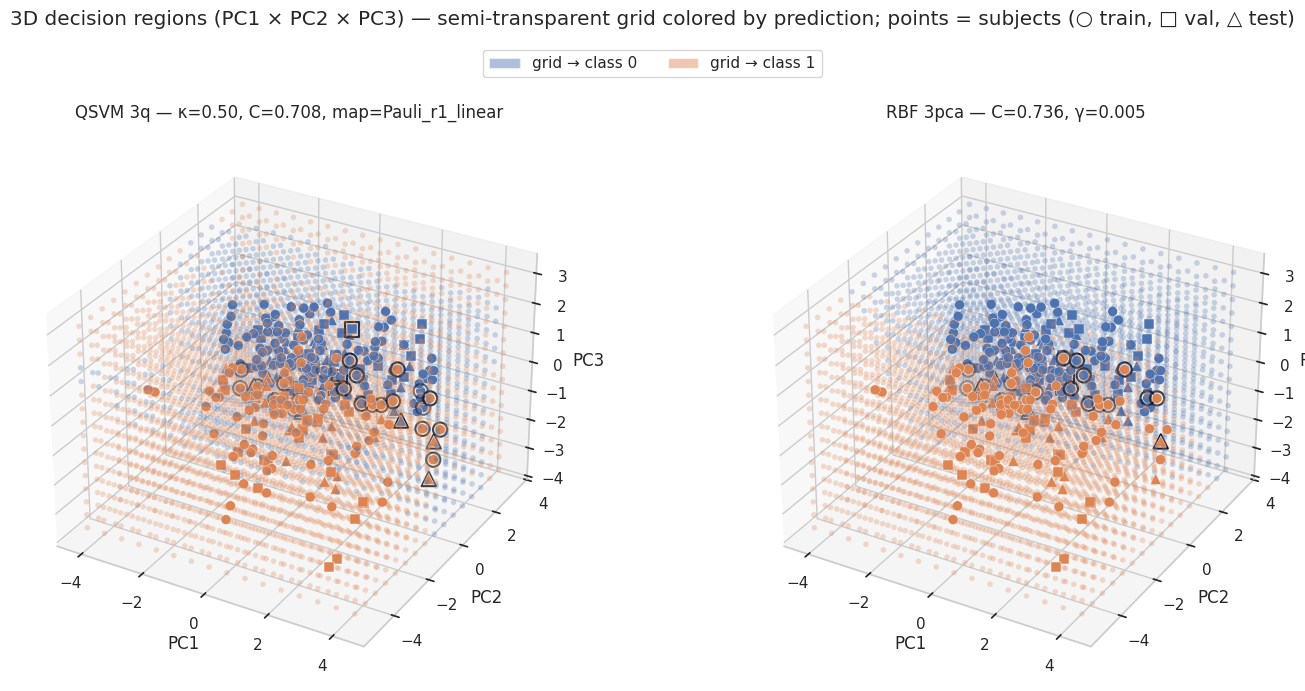

In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers projection="3d"
from matplotlib.patches import Patch

GRID_N_3D = 16  # grid points per axis (16³ ≈ 4k kernel evals per panel)


def stack_case_for_plot_3d(case, preds_by_split):
    rows = []
    for split in ("train", "val", "test"):
        Xp = getattr(case, f"X_{split}_pca")[:, :3]
        y_true = getattr(case, f"y_{split}")
        y_pred = preds_by_split[split]
        for i in range(len(y_true)):
            rows.append({
                "pc1": Xp[i, 0], "pc2": Xp[i, 1], "pc3": Xp[i, 2],
                "y_true": int(y_true[i]), "y_pred": int(y_pred[i]), "split": split,
            })
    return pd.DataFrame(rows)


def _pca_bounds_3d(case, pad=0.55):
    X_all = np.vstack([case.X_train_pca, case.X_val_pca, case.X_test_pca])[:, :3]
    return X_all.min(axis=0) - pad, X_all.max(axis=0) + pad


def _mesh_grid_3d(lo, hi, grid_n):
    lin = [np.linspace(lo[i], hi[i], grid_n) for i in range(3)]
    xx, yy, zz = np.meshgrid(*lin, indexing="ij")
    return np.c_[xx.ravel(), yy.ravel(), zz.ravel()]


def paint_decision_regions_3d(ax, grid_xyz, pred, *, s=16, alpha=0.28):
    """Color the 3D volume by predicted class (dense grid scatter)."""
    for cls in (0, 1):
        m = pred == cls
        if not np.any(m):
            continue
        ax.scatter(
            grid_xyz[m, 0], grid_xyz[m, 1], grid_xyz[m, 2],
            c=[CLASS_COLORS[cls]], s=s, alpha=alpha, depthshade=True, edgecolors="none",
        )


def scatter_classified_3d(ax, plot_df, title):
    for split, marker in SPLIT_MARKERS.items():
        sub = plot_df[plot_df["split"] == split]
        for label in (0, 1):
            m = sub[sub["y_true"] == label]
            ax.scatter(
                m["pc1"], m["pc2"], m["pc3"],
                c=[CLASS_COLORS[label]], marker=marker,
                s=52 if split != "test" else 64, alpha=0.98, depthshade=True,
                edgecolors="white", linewidths=0.35,
            )
        wrong = sub[sub["y_true"] != sub["y_pred"]]
        if len(wrong):
            ax.scatter(
                wrong["pc1"], wrong["pc2"], wrong["pc3"],
                facecolors="none", edgecolors="k", s=105, linewidths=1.5, marker=marker,
            )
    ax.set_title(title, pad=12)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")


def plot_boundary_qsvm_3d(ax, case, q_kernel, kappa, C, angle_scaler, grid_n=GRID_N_3D):
    lo, hi = _pca_bounds_3d(case)
    grid = _mesh_grid_3d(lo, hi, grid_n)
    X_train_q = np.clip(angle_scaler.transform(case.X_train_pca) * kappa, 0, np.pi)
    grid_q = np.clip(angle_scaler.transform(grid) * kappa, 0, np.pi)
    K_train = evaluate_kernel_matrix(q_kernel, X_train_q)
    K_grid = evaluate_kernel_matrix(q_kernel, grid_q, X_train_q)
    svc = SVC(kernel="precomputed", C=C, class_weight=QSVM_CLASS_WEIGHT).fit(K_train, case.y_train)
    paint_decision_regions_3d(ax, grid, svc.predict(K_grid))


def plot_boundary_rbf_3d(ax, case_obj, best_row, grid_n=GRID_N_3D):
    lo, hi = _pca_bounds_3d(case_obj)
    grid = _mesh_grid_3d(lo, hi, grid_n)
    est = make_rbf_svc(best_row).fit(case_obj.X_train_feat, case_obj.y_train)
    paint_decision_regions_3d(ax, grid, est.predict(grid))


fig = plt.figure(figsize=(15, 6.5))
ax_q = fig.add_subplot(1, 2, 1, projection="3d")
ax_r = fig.add_subplot(1, 2, 2, projection="3d")

plot_boundary_qsvm_3d(ax_q, case_3q, quantum_kernel_3q, BEST_KAPPA_3Q, BEST_C_3Q, angle_3q)
scatter_classified_3d(
    ax_q, stack_case_for_plot_3d(case_3q, preds_3q),
    f"QSVM 3q — κ={BEST_KAPPA_3Q:.2f}, C={BEST_C_3Q:.3g}, map={best_3['name']}",
)

plot_boundary_rbf_3d(ax_r, case_3q, best_rbf_3)
scatter_classified_3d(
    ax_r, stack_case_for_plot_3d(case_3q, preds_rbf_3),
    f"RBF 3pca — C={BEST_C_RBF_3:.3g}, γ={BEST_GAMMA_RBF_3}",
)

region_handles = [
    Patch(facecolor=CLASS_COLORS[0], alpha=0.45, label="grid → class 0"),
    Patch(facecolor=CLASS_COLORS[1], alpha=0.45, label="grid → class 1"),
]
fig.legend(handles=region_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.01), frameon=True)
fig.suptitle(
    "3D decision regions (PC1 × PC2 × PC3) — semi-transparent grid colored by prediction; "
    "points = subjects (○ train, □ val, △ test)",
    y=1.06,
)
plt.tight_layout()
plt.show()


In [10]:
from data_io import inner_train_val_row_split, subject_level_kfold_row_splits

CV_BRANCHES = [
    {"qsvm": "qsvm_2q", "rbf": "rbf_2pca", "n_components": N_COMPONENTS_2Q, "use_pca": True},
    {"qsvm": "qsvm_3q", "rbf": "rbf_3pca", "n_components": N_COMPONENTS_3Q, "use_pca": True},
    {"qsvm": "qsvm_4q", "rbf": "rbf_4pca", "n_components": N_COMPONENTS, "use_pca": True},
    {"qsvm": "qsvm_8q", "rbf": "rbf_8pca", "n_components": N_COMPONENTS_8Q, "use_pca": True},
    {"qsvm": "qsvm_all", "rbf": "rbf_11f", "n_components": None, "use_pca": False},
]


@dataclass
class FoldData:
    X_train_feat: np.ndarray
    X_val_feat: np.ndarray
    X_test_feat: np.ndarray
    X_train_q: np.ndarray
    X_val_q: np.ndarray
    X_test_q: np.ndarray
    y_train: np.ndarray
    y_val: np.ndarray
    y_test: np.ndarray
    n_features: int


def prepare_fold(
    X_arr: np.ndarray,
    y_arr: np.ndarray,
    subject_ids: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    *,
    n_components: int | None,
    use_pca: bool,
    inner_val_frac: float,
    inner_seed: int,
    pca_seed: int,
) -> FoldData:
    sub_train, sub_val = inner_train_val_row_split(
        train_idx, subject_ids, y_arr, inner_val_frac, inner_seed
    )

    scaler = StandardScaler()
    X_sub_tr = scaler.fit_transform(X_arr[sub_train])
    X_sub_va = scaler.transform(X_arr[sub_val])
    X_te = scaler.transform(X_arr[test_idx])

    if use_pca:
        n_comp = min(n_components, X_arr.shape[1], len(sub_train) - 1)
        pca = PCA(n_components=n_comp, random_state=pca_seed)
        X_sub_tr_f = pca.fit_transform(X_sub_tr)
        X_sub_va_f = pca.transform(X_sub_va)
        X_te_f = pca.transform(X_te)
        n_feat = n_comp
    else:
        X_sub_tr_f, X_sub_va_f, X_te_f = X_sub_tr, X_sub_va, X_te
        n_feat = X_arr.shape[1]

    angle = MinMaxScaler(feature_range=(0.0, np.pi))
    X_sub_tr_q = angle.fit_transform(X_sub_tr_f)
    X_sub_va_q = np.clip(angle.transform(X_sub_va_f), 0.0, np.pi)
    X_te_q = np.clip(angle.transform(X_te_f), 0.0, np.pi)

    return FoldData(
        X_sub_tr_f, X_sub_va_f, X_te_f,
        X_sub_tr_q, X_sub_va_q, X_te_q,
        y_arr[sub_train], y_arr[sub_val], y_arr[test_idx],
        n_feat,
    )


def pick_best_feature_map_fold(fold: FoldData):
    rows = []
    for spec in FEATURE_MAP_GRID:
        fm = make_feature_map(spec["kind"], fold.n_features, spec["reps"], spec["entanglement"])
        qk = FidelityStatevectorKernel(feature_map=fm, enforce_psd=True)
        X_tr = transform_with_kappa(fold.X_train_q, 1.0)
        X_va = transform_with_kappa(fold.X_val_q, 1.0)
        K_tr = evaluate_kernel_matrix(qk, X_tr)
        K_va = evaluate_kernel_matrix(qk, X_va, X_tr)
        m = SVC(kernel="precomputed", C=1.0, class_weight=QSVM_CLASS_WEIGHT)
        m.fit(K_tr, fold.y_train)
        val_f1 = float(f1_score(fold.y_val, m.predict(K_va), zero_division=0))
        rows.append({**spec, "val_f1": val_f1, "feature_map": fm})
    table = pd.DataFrame(rows).sort_values("val_f1", ascending=False)
    return rows[int(table.index[0])]


def tune_qsvm_fold(q_kernel, fold: FoldData):
    return tune_qsvm_on_validation(q_kernel, fold, KAPPA_GRID, C_GRID)[:2]


def tune_rbf_fold(fold: FoldData):
    best, _ = tune_rbf(fold, RBF_C_GRID, GAMMA_GRID, RBF_CLASS_WEIGHT)
    return best


def eval_qsvm_fold(q_kernel, fold: FoldData, kappa: float, C: float):
    X_tr = transform_with_kappa(fold.X_train_q, kappa)
    X_te = transform_with_kappa(fold.X_test_q, kappa)
    K_tr = evaluate_kernel_matrix(q_kernel, X_tr)
    K_te = evaluate_kernel_matrix(q_kernel, X_te, X_tr)
    m = SVC(kernel="precomputed", C=C, class_weight=QSVM_CLASS_WEIGHT)
    m.fit(K_tr, fold.y_train)
    pred = m.predict(K_te)
    return pred, fold.y_test


def eval_rbf_fold(fold: FoldData, best_row):
    m = make_rbf_svc(best_row)
    m.fit(fold.X_train_feat, fold.y_train)
    pred = m.predict(fold.X_test_feat)
    return pred, fold.y_test


In [11]:
cv_rows = []

for fold_i, (train_idx, test_idx) in enumerate(
    subject_level_kfold_row_splits(subjects, y, N_FOLDS, CV_SEED)
):
    print(f"\n=== CV fold {fold_i + 1}/{N_FOLDS} (test rows={len(test_idx)}, subjects={len(np.unique(subjects[test_idx]))}) ===")
    for br in CV_BRANCHES:
        n_comp = br["n_components"] if br["use_pca"] else X.shape[1]
        fd = prepare_fold(
            X, y, subjects, train_idx, test_idx,
            n_components=n_comp,
            use_pca=br["use_pca"],
            inner_val_frac=INNER_VAL_FRAC,
            inner_seed=INNER_VAL_SEED + fold_i,
            pca_seed=CV_SEED + fold_i,
        )
        best_fm = pick_best_feature_map_fold(fd)
        qk = FidelityStatevectorKernel(feature_map=best_fm["feature_map"], enforce_psd=True)
        kappa, C = tune_qsvm_fold(qk, fd)
        pred_q, y_te = eval_qsvm_fold(qk, fd, kappa, C)
        cv_rows.append({
            "fold": fold_i,
            "model": br["qsvm"],
            "f1": float(f1_score(y_te, pred_q, zero_division=0)),
            "accuracy": float(accuracy_score(y_te, pred_q)),
            "fm": best_fm["name"],
            "kappa": kappa,
            "C": C,
            "gamma": None,
        })
        print(f"  {br['qsvm']}: fm={best_fm['name']} κ={kappa:.2f} C={C:.3g} test F1={cv_rows[-1]['f1']:.3f}")

        best_rbf = tune_rbf_fold(fd)
        pred_r, y_te = eval_rbf_fold(fd, best_rbf)
        cv_rows.append({
            "fold": fold_i,
            "model": br["rbf"],
            "f1": float(f1_score(y_te, pred_r, zero_division=0)),
            "accuracy": float(accuracy_score(y_te, pred_r)),
            "fm": None,
            "kappa": None,
            "C": float(best_rbf["C"]),
            "gamma": best_rbf["gamma"],
        })
        print(f"  {br['rbf']}: C={best_rbf['C']:.3g} γ={best_rbf['gamma']} test F1={cv_rows[-1]['f1']:.3f}")

cv_df = pd.DataFrame(cv_rows)
display(cv_df)



=== CV fold 1/5 (test rows=64, subjects=26) ===
  qsvm_2q: fm=Z_r1 κ=0.25 C=17.3 test F1=0.741
  rbf_2pca: C=0.117 γ=0.005 test F1=0.730
  qsvm_3q: fm=Pauli_r1_linear κ=1.00 C=17.3 test F1=0.767
  rbf_3pca: C=0.0631 γ=0.01 test F1=0.857
  qsvm_4q: fm=Z_r1 κ=0.25 C=2.05 test F1=0.898
  rbf_4pca: C=29.3 γ=0.001 test F1=0.920
  qsvm_8q: fm=Z_r1 κ=0.25 C=2.05 test F1=0.980
  rbf_8pca: C=8.58 γ=0.001 test F1=0.960
  qsvm_all: fm=Z_r1 κ=0.25 C=0.708 test F1=0.980
  rbf_11f: C=4.64 γ=0.001 test F1=0.917

=== CV fold 2/5 (test rows=65, subjects=26) ===
  qsvm_2q: fm=Z_r1 κ=0.25 C=0.244 test F1=0.833
  rbf_2pca: C=2.51 γ=0.001 test F1=0.833
  qsvm_3q: fm=ZZ_r1_linear κ=0.25 C=2.05 test F1=0.754
  rbf_3pca: C=54.1 γ=0.03 test F1=0.836
  qsvm_4q: fm=Z_r1 κ=0.25 C=2.05 test F1=0.857
  rbf_4pca: C=4.64 γ=0.005 test F1=0.885
  qsvm_8q: fm=Z_r1 κ=0.25 C=0.244 test F1=0.917
  rbf_8pca: C=4.64 γ=0.001 test F1=0.943
  qsvm_all: fm=Z_r1 κ=0.25 C=0.708 test F1=0.981
  rbf_11f: C=4.64 γ=0.001 test F1=0.98

,fold,model,f1,accuracy,fm,kappa,C,gamma
0,0,qsvm_2q,0.740741,0.781250,Z_r1,0.25,17.278260,NaN
1,0,rbf_2pca,0.730159,0.734375,NaN,NaN,0.116591,0.005
2,0,qsvm_3q,0.766667,0.781250,Pauli_r1_linear,1.00,17.278260,NaN
3,0,rbf_3pca,0.857143,0.875000,NaN,NaN,0.063096,0.010
4,0,qsvm_4q,0.897959,0.921875,Z_r1,0.25,2.053525,NaN
5,0,rbf_4pca,0.920000,0.937500,NaN,NaN,29.286446,0.001
6,0,qsvm_8q,0.980392,0.984375,Z_r1,0.25,2.053525,NaN
7,0,rbf_8pca,0.960000,0.968750,NaN,NaN,8.576959,0.001
8,0,qsvm_all,0.980392,0.984375,Z_r1,0.25,0.707946,NaN
9,0,rbf_11f,0.916667,0.937500,NaN,NaN,4.641589,0.001


,model,f1_mean,f1_std,acc_mean,acc_std,f1_mean_std
0,qsvm_2q,0.820370,0.072198,0.859059,0.057828,0.820 ± 0.072
1,qsvm_3q,0.813120,0.104012,0.842060,0.092208,0.813 ± 0.104
2,qsvm_4q,0.918079,0.053201,0.938161,0.040582,0.918 ± 0.053
3,qsvm_8q,0.975490,0.034314,0.981537,0.025280,0.975 ± 0.034
4,qsvm_all,0.962333,0.041394,0.972297,0.029115,0.962 ± 0.041
5,rbf_11f,0.966943,0.032060,0.975044,0.023802,0.967 ± 0.032
6,rbf_2pca,0.817723,0.067584,0.840449,0.075547,0.818 ± 0.068
7,rbf_3pca,0.864967,0.080049,0.885692,0.071776,0.865 ± 0.080
8,rbf_4pca,0.928722,0.043747,0.944363,0.035201,0.929 ± 0.044
9,rbf_8pca,0.976758,0.024937,0.981489,0.020143,0.977 ± 0.025


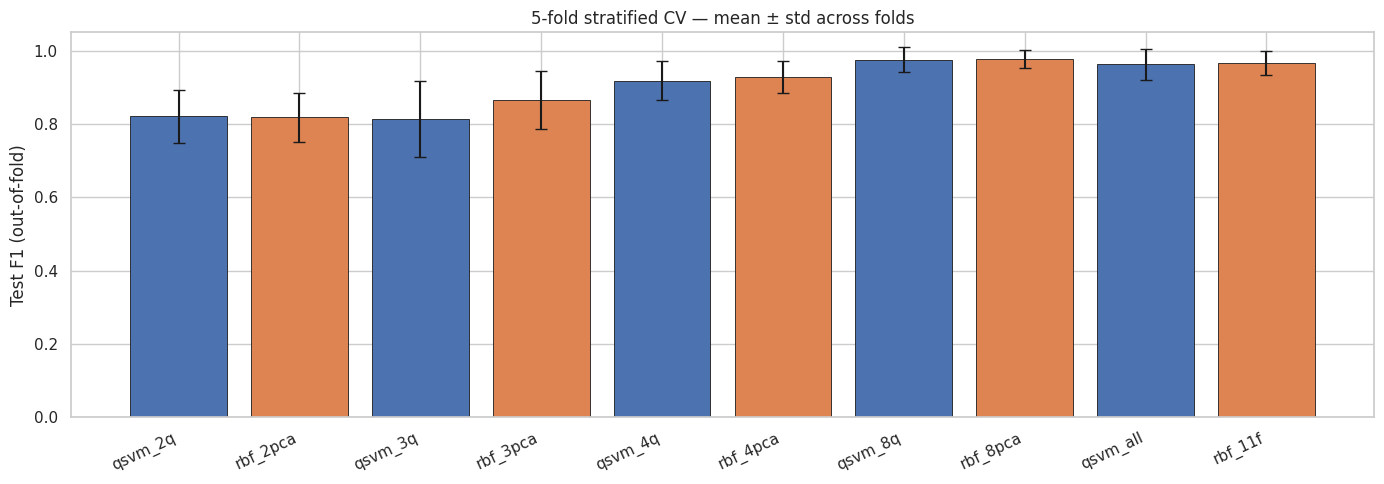

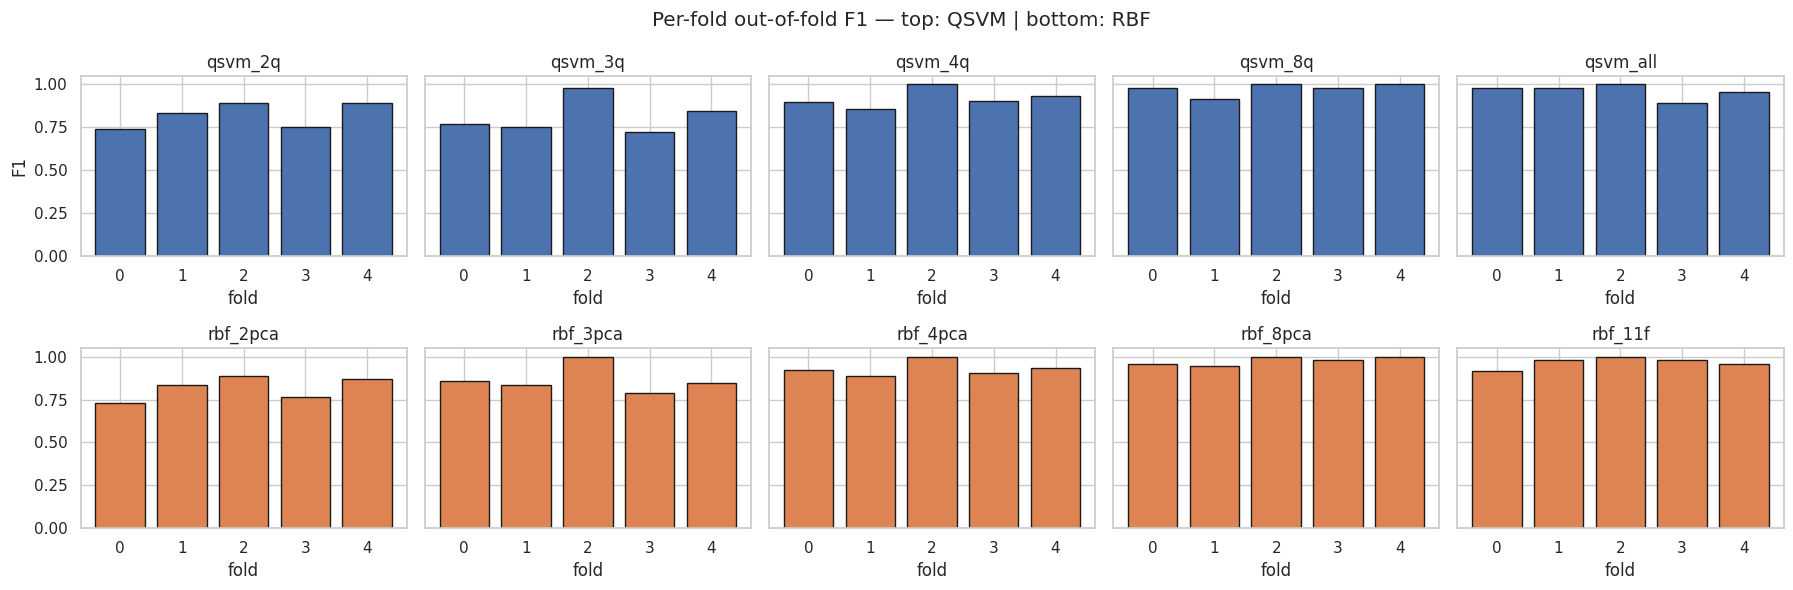

saved /workspaces/QML/hackathon/challenge-02-dementia-classifier/results/kfold_metrics_2q3q.json


In [12]:
cv_summary = (
    cv_df.groupby("model", as_index=False)
    .agg(
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),
    )
    .sort_values("model")
)
cv_summary["f1_mean_std"] = cv_summary.apply(
    lambda r: f"{r['f1_mean']:.3f} ± {r['f1_std']:.3f}", axis=1
)
display(cv_summary)

model_order = [
    "qsvm_2q", "rbf_2pca", "qsvm_3q", "rbf_3pca", "qsvm_4q", "rbf_4pca",
    "qsvm_8q", "rbf_8pca", "qsvm_all", "rbf_11f",
]
plot_df = cv_summary.set_index("model").reindex(model_order).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#4C72B0" if m.startswith("qsvm") else "#DD8452" for m in plot_df["model"]]
ax.bar(
    plot_df["model"], plot_df["f1_mean"], yerr=plot_df["f1_std"],
    capsize=4, color=colors, edgecolor="k", linewidth=0.6,
)
ax.set_ylabel("Test F1 (out-of-fold)")
ax.set_title(f"{N_FOLDS}-fold stratified CV — mean ± std across folds")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

fig2, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=True)
for col, (q_name, r_name) in enumerate([
    ("qsvm_2q", "rbf_2pca"), ("qsvm_3q", "rbf_3pca"), ("qsvm_4q", "rbf_4pca"),
    ("qsvm_8q", "rbf_8pca"), ("qsvm_all", "rbf_11f"),
]):
    for row, name in enumerate([q_name, r_name]):
        sub = cv_df[cv_df["model"] == name]
        axes[row, col].bar(sub["fold"], sub["f1"], color=colors[row], edgecolor="k")
        axes[row, col].set_title(name)
        axes[row, col].set_ylim(0, 1.05)
        axes[row, col].set_xlabel("fold")
axes[0, 0].set_ylabel("F1")
fig2.suptitle("Per-fold out-of-fold F1 — top: QSVM | bottom: RBF")
plt.tight_layout()
plt.show()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
cv_out = {
    "data_source": DATA_SOURCE,
    "protocol": {
        "n_folds": N_FOLDS,
        "cv_seed": CV_SEED,
        "inner_val_frac": INNER_VAL_FRAC,
        "rbf_grid": {"C": "RBF_C_GRID", "gamma": "GAMMA_GRID", "selection": "max val_f1, tie-break smaller gamma"},
        "subject_level": True,
    },
    "per_fold": cv_df.to_dict(orient="records"),
    "summary": cv_summary.drop(columns=["f1_mean_std"]).to_dict(orient="records"),
}
with open(RESULTS_DIR / "kfold_metrics_2q3q.json", "w") as f:
    json.dump(cv_out, f, indent=2, default=float)
print("saved", RESULTS_DIR / "kfold_metrics_2q3q.json")
